In [1]:
!pip install datasets transformers scikit-learn evaluate --quiet

In [2]:
from datasets import load_dataset

ds = load_dataset("imdb")

print("Train size:", len(ds["train"]))
print("Test size :", len(ds["test"]))
print("Labels:", ds["train"].features["label"].names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Train size: 25000
Test size : 25000
Labels: ['neg', 'pos']


In [3]:
from sklearn.model_selection import train_test_split

train_texts  = list(ds["train"]["text"])
train_labels = list(ds["train"]["label"])

X_train, X_val, y_train, y_val = train_test_split(
    train_texts,
    train_labels,
    test_size=0.10,
    random_state=42,
    stratify=train_labels
)

print("New training size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(ds["test"]))

New training size: 22500
Validation size: 2500
Test size: 25000


In [4]:
import pandas as pd

splits_df = pd.DataFrame({
    "text": X_train + X_val,
    "label": y_train + y_val,
    "split": (["train"] * len(X_train)) + (["val"] * len(X_val))
})

test_df = pd.DataFrame({
    "text": list(ds["test"]["text"]),
    "label": list(ds["test"]["label"]),
    "split": ["test"] * len(ds["test"])
})

all_splits = pd.concat([splits_df, test_df], ignore_index=True)

print(all_splits["split"].value_counts())

split
test     25000
train    22500
val       2500
Name: count, dtype: int64


In [5]:
all_splits.to_csv("imdb_splits.csv", index=False)
print("Saved:", "imdb_splits.csv")

Saved: imdb_splits.csv


In [6]:
all_splits.head(3)

,text,label,split
0,"""Algie, the Miner"" is one bad and unfunny sile...",0,train
1,This is a complete Hoax...<br /><br />The movi...,0,train
2,"Nifty little episode played mainly for laughs,...",1,train


In [7]:
import re

def basic_preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


all_splits["text_clean"] = all_splits["text"].apply(basic_preprocess)

print(all_splits[["split", "text", "text_clean"]].head(2))

   split                                               text  \
0  train  "Algie, the Miner" is one bad and unfunny sile...   
1  train  This is a complete Hoax...<br /><br />The movi...   

                                          text_clean  
0  "algie, the miner" is one bad and unfunny sile...  
1  this is a complete hoax...<br /><br />the movi...  


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Separate splits again
train_data = all_splits[all_splits["split"] == "train"]
val_data   = all_splits[all_splits["split"] == "val"]
test_data  = all_splits[all_splits["split"] == "test"]

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(train_data["text_clean"])
X_val_tfidf   = vectorizer.transform(val_data["text_clean"])
X_test_tfidf  = vectorizer.transform(test_data["text_clean"])

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF val shape:", X_val_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (22500, 20000)
TF-IDF val shape: (2500, 20000)
TF-IDF test shape: (25000, 20000)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import time

y_train = train_data["label"]
y_val   = val_data["label"]
y_test  = test_data["label"]

# Initializing model
lr_model = LogisticRegression(max_iter=1000)

# Measure training time
start_time = time.time()
lr_model.fit(X_train_tfidf, y_train)
training_time = time.time() - start_time

print("Training time (seconds):", training_time)

Training time (seconds): 1.1624486446380615


In [22]:
# Measureing inference time on testing set
start_time = time.time()
y_pred_lr = lr_model.predict(X_test_tfidf)
inference_time = time.time() - start_time

# Metrics
acc = accuracy_score(y_test, y_pred_lr)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_lr, average="binary")

print("Inference time (seconds):", inference_time)
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

# Error rate (for failure analysis)
error_rate = 1 - acc
print("Error rate:", error_rate)

# Collect wrong predictions
wrong_cases = []

for text, pred, true in zip(test_data["text"], y_pred_lr, y_test):
    if pred != true:
        wrong_cases.append({
            "text": text,
            "predicted": int(pred),
            "true": int(true)
        })

print("Number of wrong predictions:", len(wrong_cases))
print("Example mistake:\n", wrong_cases[0])

Inference time (seconds): 0.01912856101989746
Accuracy: 0.89296
Precision: 0.8903369357914812
Recall: 0.89632
F1-score: 0.8933184500079732
Error rate: 0.10704000000000002
Number of wrong predictions: 2676
Example mistake:
 {'text': "First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other action guys (Segal and Dolph) have thought about putting out the past few years. Van Damme is good in the movie, the movie is only worth watching to Van Damme fans. It is not as good as Wake of Death (which i highly recommend to anyone of likes Van Damme) or In hell but, in my opinion it's worth watching. It has the same type of feel to it as Nowhere to Run. Good fun stuff!", 'predicted': 1, 'true': 0}


In [11]:
import time
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

svm_model = LinearSVC()

# training time
start_time = time.time()
svm_model.fit(X_train_tfidf, y_train)
svm_training_time = time.time() - start_time

print("SVM Training time (seconds):", svm_training_time)

SVM Training time (seconds): 1.4778459072113037


In [23]:
# Measure inference time on test set
start_time = time.time()
y_pred_svm = svm_model.predict(X_test_tfidf)
inference_time = time.time() - start_time

# Metrics
acc = accuracy_score(y_test, y_pred_svm)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_svm, average="binary")

print("Inference time (seconds):", inference_time)
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

# Error rate
error_rate = 1 - acc
print("Error rate:", error_rate)

# Collect wrong predictions
svm_wrong_cases = []

for text, pred, true in zip(test_data["text"], y_pred_svm, y_test):
    if pred != true:
        svm_wrong_cases.append({
            "text": text,
            "predicted": int(pred),
            "true": int(true)
        })

print("Number of wrong predictions:", len(svm_wrong_cases))
print("Example mistake:\n", svm_wrong_cases[0])

Inference time (seconds): 0.03264737129211426
Accuracy: 0.89088
Precision: 0.8910051216389244
Recall: 0.89072
F1-score: 0.890862538006081
Error rate: 0.10912
Number of wrong predictions: 2728
Example mistake:
 {'text': "First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other action guys (Segal and Dolph) have thought about putting out the past few years. Van Damme is good in the movie, the movie is only worth watching to Van Damme fans. It is not as good as Wake of Death (which i highly recommend to anyone of likes Van Damme) or In hell but, in my opinion it's worth watching. It has the same type of feel to it as Nowhere to Run. Good fun stuff!", 'predicted': 1, 'true': 0}


In [13]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded.")

Tokenizer loaded.


In [14]:
from datasets import Dataset

# Converting pandas to HF datasets
train_hf = Dataset.from_pandas(train_data[["text_clean", "label"]].rename(columns={"text_clean":"text"}))
val_hf   = Dataset.from_pandas(val_data[["text_clean", "label"]].rename(columns={"text_clean":"text"}))
test_hf  = Dataset.from_pandas(test_data[["text_clean", "label"]].rename(columns={"text_clean":"text"}))

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)

train_tok = train_hf.map(tokenize_batch, batched=True)
val_tok   = val_hf.map(tokenize_batch, batched=True)
test_tok  = test_hf.map(tokenize_batch, batched=True)

# Set format for PyTorch
train_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print(train_tok[0])

Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

{'label': tensor(0), 'input_ids': tensor([  101,  1000,  2632, 11239,  1010,  1996, 18594,  1000,  2003,  2028,
         2919,  1998,  4895, 11263, 10695,  2100,  4333,  4038,  1012,  1996,
        10984,  1997,  1996, 14308, 21354,  2003,  3294,  2125,  1012,  2023,
         2003,  1996,  2785,  1997,  8562,  2007,  3056, 10071,  2008,  2191,
         2017,  4687,  2065,  2027,  1005,  2128,  4011,  2000,  2022,  6057,
         2030,  2025,  1012,  2174,  1010,  1996,  5025,  3737,  1997,  1996,
         2143,  2003, 22537,  1012,  2023,  2003, 10915, 10523,  2005,  2143,
        23176,  2015,  3701,  2138,  2049,  2028,  1997,  1996,  5700,  4973,
         1997,  5637,  5988,  1012,  1996,  2364,  2839,  1997,  2632, 11239,
         2003,  2019,  1041, 16020, 19269,  3124,  1010,  3772,  2172,  2066,
         1996, 12991, 27086,  1000,  6090,  6508,  1000,  2691,  1999,  2116,
         2220,  3152,  1012,  1996,  2143,  2038,  1996, 24004, 20200,  7729,
         2691,  1997,  1996,  

In [15]:
from transformers import AutoModelForSequenceClassification

bert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

print("Model loaded.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.


In [16]:
import numpy as np
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import time

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

training_args = TrainingArguments(
    output_dir="./distilbert_imdb",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    logging_steps=100,
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics
)

print("Trainer ready.")

Trainer ready.


In [17]:
import time

start_time = time.time()
trainer.train()
bert_training_time = time.time() - start_time

print("DistilBERT Training time (seconds):", bert_training_time)

Step,Training Loss
100,0.472537
200,0.354532
300,0.321673
400,0.318267
500,0.318031
600,0.302914
700,0.284534
800,0.264256
900,0.272101
1000,0.257889


DistilBERT Training time (seconds): 535.6918754577637


In [18]:
import time
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Inference time + predictions on test
start_time = time.time()
pred_output = trainer.predict(test_tok)
bert_inference_time = time.time() - start_time

logits = pred_output.predictions
y_pred = np.argmax(logits, axis=1)
y_true = pred_output.label_ids

# Metrics
acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)

print("DistilBERT Inference time (seconds):", bert_inference_time)
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

# Error rate (for failure analysis)
bert_error_rate = 1 - acc
print("Error rate:", bert_error_rate)

# Collect wrong predictions (for analysis)
bert_wrong_cases = []

for text, pred, true in zip(test_data["text"], y_pred, y_true):
    if pred != true:
        bert_wrong_cases.append({
            "text": text,
            "predicted": int(pred),
            "true": int(true)
        })

print("Number of wrong predictions:", len(bert_wrong_cases))
print("Example mistake:\n", bert_wrong_cases[0])

DistilBERT Inference time (seconds): 203.39688062667847
Accuracy: 0.91036
Precision: 0.9073941704392026
Recall: 0.914
F1-score: 0.9106851062133833
Error rate: 0.08964000000000005
Number of wrong predictions: 2241
Example mistake:
 {'text': "First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other action guys (Segal and Dolph) have thought about putting out the past few years. Van Damme is good in the movie, the movie is only worth watching to Van Damme fans. It is not as good as Wake of Death (which i highly recommend to anyone of likes Van Damme) or In hell but, in my opinion it's worth watching. It has the same type of feel to it as Nowhere to Run. Good fun stuff!", 'predicted': 1, 'true': 0}


In [20]:
import pandas as pd

results = pd.DataFrame([
    {
        "Model": "Logistic Regression (TF-IDF)",
        "Train_time_s": 1.0212,
        "Inference_time_s": 0.01323,
        "Accuracy": 0.89296,
        "Precision": 0.89034,
        "Recall": 0.89632,
        "F1": 0.89332
    },
    {
        "Model": "Linear SVM (TF-IDF)",
        "Train_time_s": 5.1542,
        "Inference_time_s": 0.02925,
        "Accuracy": 0.89088,
        "Precision": 0.89101,
        "Recall": 0.89072,
        "F1": 0.89086
    },
    {
        "Model": "DistilBERT (1 epoch)",
        "Train_time_s": 518.5045,
        "Inference_time_s": 203.3969,
        "Accuracy": 0.91036,
        "Precision": 0.90739,
        "Recall": 0.91400,
        "F1": 0.91069
    }
])

results

,Model,Train_time_s,Inference_time_s,Accuracy,Precision,Recall,F1
0,Logistic Regression (TF-IDF),1.0212,0.01323,0.89296,0.89034,0.89632,0.89332
1,Linear SVM (TF-IDF),5.1542,0.02925,0.89088,0.89101,0.89072,0.89086
2,DistilBERT (1 epoch),518.5045,203.39690,0.91036,0.90739,0.91400,0.91069


In [24]:
from sklearn.metrics import confusion_matrix

# Logistic Regression
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

# SVM
print("\nSVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

# DistilBERT
print("\nDistilBERT Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Logistic Regression Confusion Matrix:
[[11120  1380]
 [ 1296 11204]]

SVM Confusion Matrix:
[[11138  1362]
 [ 1366 11134]]

DistilBERT Confusion Matrix:
[[11334  1166]
 [ 1075 11425]]


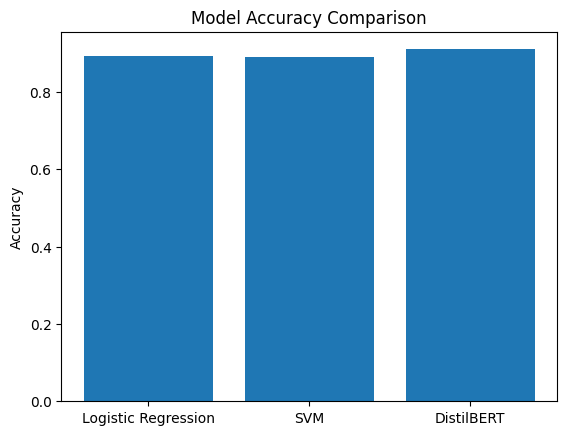

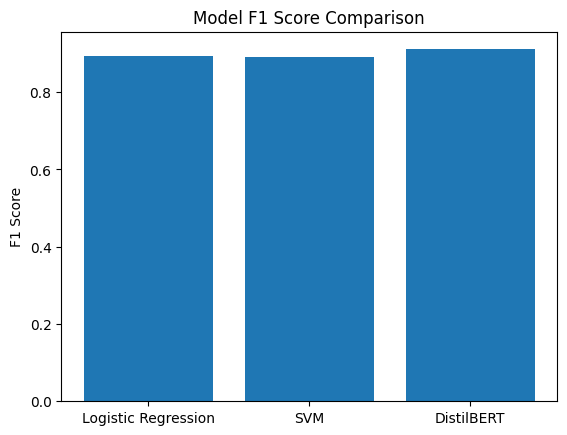

In [25]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "SVM", "DistilBERT"]
accuracy = [0.89296, 0.89088, 0.91036]
f1 = [0.89332, 0.89086, 0.91069]

x = range(len(models))

plt.figure()
plt.bar(x, accuracy)
plt.xticks(x, models)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.bar(x, f1)
plt.xticks(x, models)
plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")
plt.show()

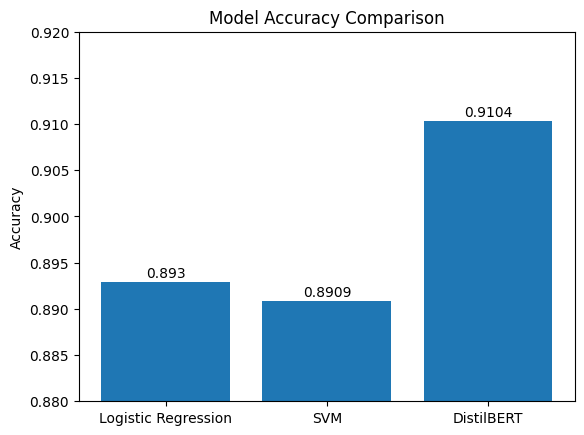

In [29]:
plt.figure()
plt.bar(x, accuracy)
plt.xticks(x, models)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.ylim(0.88, 0.92)  # 🔥 KEY LINE
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.0005, str(round(v, 4)), ha='center')

plt.show()

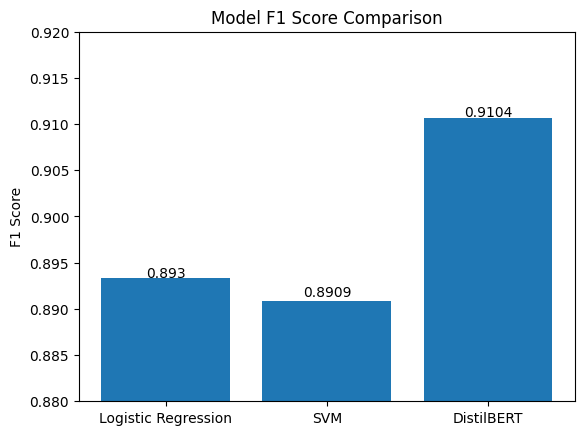

In [28]:
plt.figure()
plt.bar(x, f1)
plt.xticks(x, models)
plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")

plt.ylim(0.88, 0.92)
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.0005, str(round(v, 4)), ha='center')

plt.show()